## **Modelling - Holt + ARIMA**
**NOTE:** Train/test split currently set to 2018 (Can be adjusted later for consistency with evaluation)

In [1]:
# install.packages("forecast")
library(forecast)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [2]:
setwd("C:/Users/nilas/OneDrive - UBC/Desktop/courses 2025/Term 2/STAT 443/project")

### **Reading in Dataset and Creating Time Series Object**

In [3]:
unemp <- read.csv("unemployment_rate.csv")
unique(unemp$Labour.force.characteristics) #for my info
#extracting unemployment rate info
unemp_rate_row <- unemp[unemp$Labour.force.characteristics == "Unemployment rate", ]
#dropping the label column and converting row to vector
values <- unemp_rate_row[ , -1]
values_vec <- as.numeric(gsub(",", "", as.character(values)))

[1] "Population"           "Labour force"         "Employment"          
[4] "Full-time employment" "Part-time employment" "Unemployment"        
[7] "Unemployment rate"    "Participation rate"   "Employment rate"

### **Creating Time Series Object**

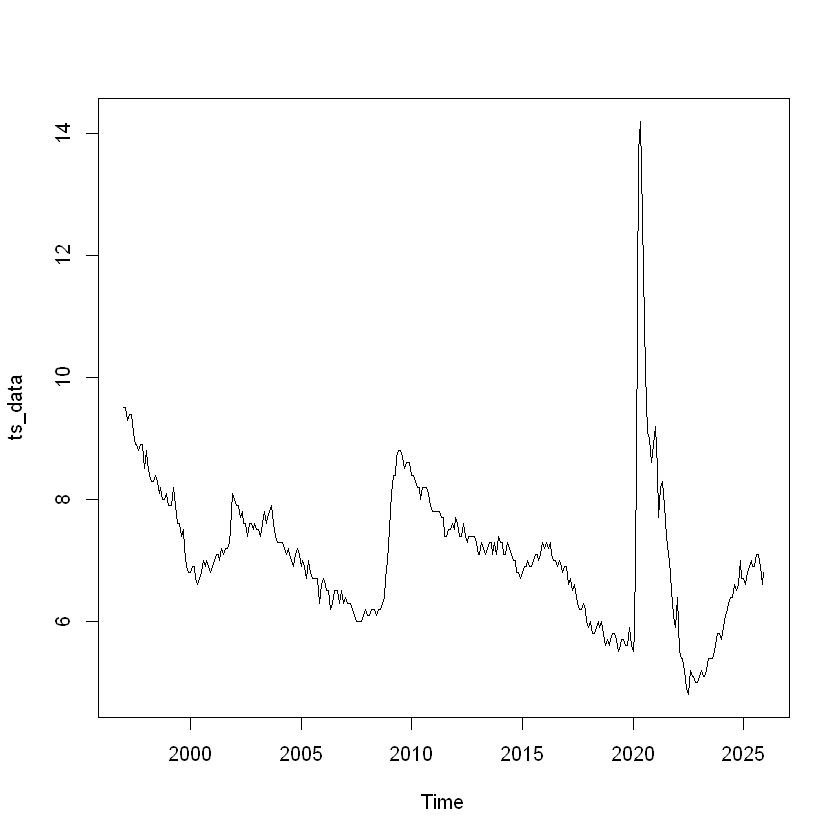

In [4]:
ts_data <- ts(values_vec, start=c(1997,1), frequency=12)
plot(ts_data)

From the above graph, we observe a smooth macro trend with a spike during COVID in the year 2020.

### **Train/Test Splits**


In [5]:
train <- window(ts_data, end=c(2018,12))
test  <- window(ts_data, start=c(2019,1))
length(train)
length(test)


[1] 264

[1] 84

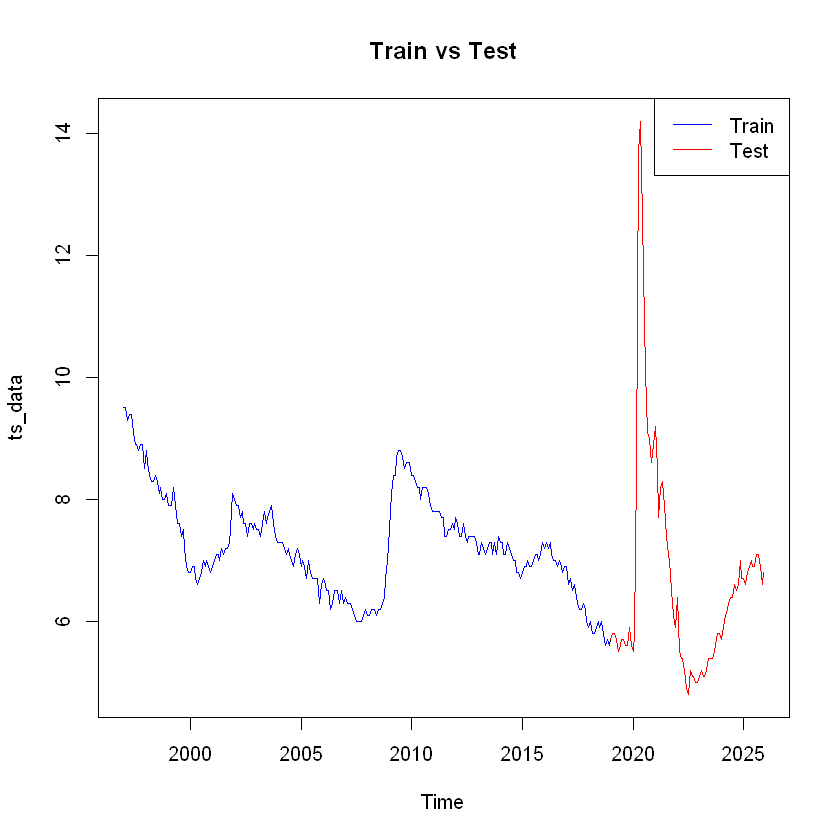

In [6]:
plot(ts_data, col="black", main="Train vs Test")
lines(train, col="blue")
lines(test, col="red")
legend("topright", legend=c("Train","Test"), col=c("blue","red"), lty=1)

### **Holt Model**

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.0002462728,0.1529177,0.1179421,-0.01206121,1.634964,0.229864,0.007036993,NA
Test set,1.7245054526,2.4753805,1.7302154,21.94592184,22.062670,3.372114,0.905270168,3.02168


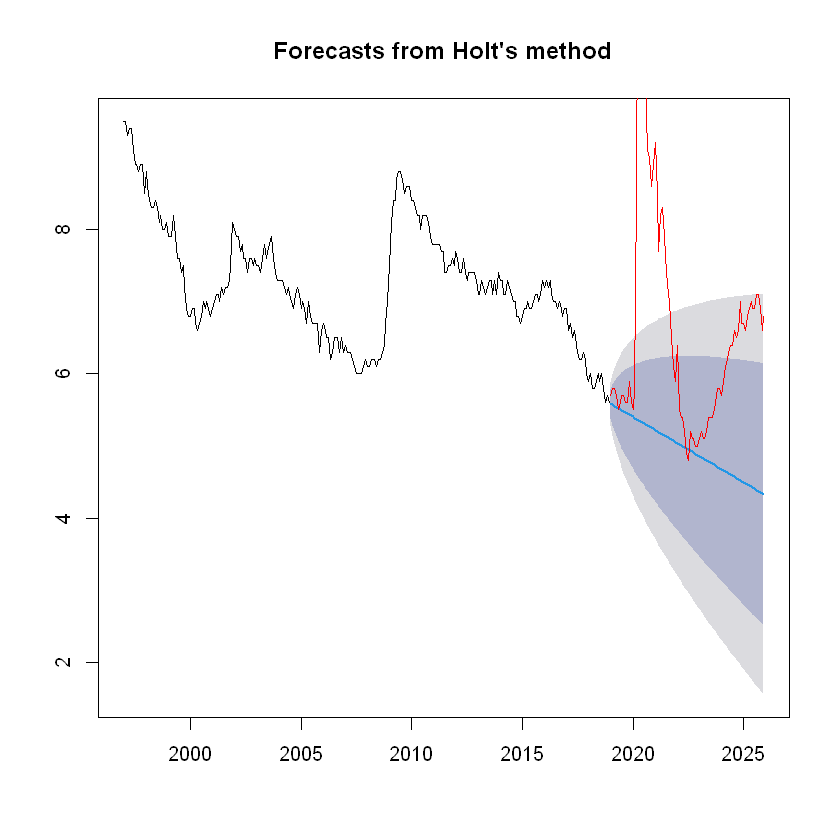

In [7]:
holt_fc <- holt(train, h = length(test))
plot(holt_fc)
lines(test, col = "red")
accuracy(holt_fc, test)

From above, we observe that the training error is low, indicating a good fit, however, the test RMSE is significantly higher (2.48), thus showing poor
forecasting performance.   

This is mainly due to the model’s inability to capture the sudden spike in unemployment during COVID-19 in 2020. Additionally, the high residual
autocorrelation (ACF1 = 0.905) suggests that the model does not fully capture the underlying time dependence in the series.


### **ARIMA model**

In [8]:
#Training set
fit_auto <- auto.arima(train)
summary(fit_auto)

Series: train 
ARIMA(1,1,1)(1,0,2)[12] 

Coefficients:
         ar1      ma1     sar1     sma1     sma2
      0.9462  -0.8632  -0.3357  -0.0186  -0.2173
s.e.  0.0414   0.0569   0.4757   0.4665   0.1768

sigma^2 = 0.02087:  log likelihood = 137.17
AIC=-262.34   AICc=-262.02   BIC=-240.91

Training set error measures:
                      ME      RMSE       MAE        MPE    MAPE      MASE
Training set -0.01028619 0.1427994 0.1108049 -0.1519841 1.52937 0.2159538
                    ACF1
Training set -0.08611533

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.01028619,0.1427994,0.1108049,-0.1519841,1.52937,0.2159538,-0.08611533,NA
Test set,1.14644263,2.1457760,1.3063259,12.7037786,15.84813,2.5459716,0.91294604,2.411667


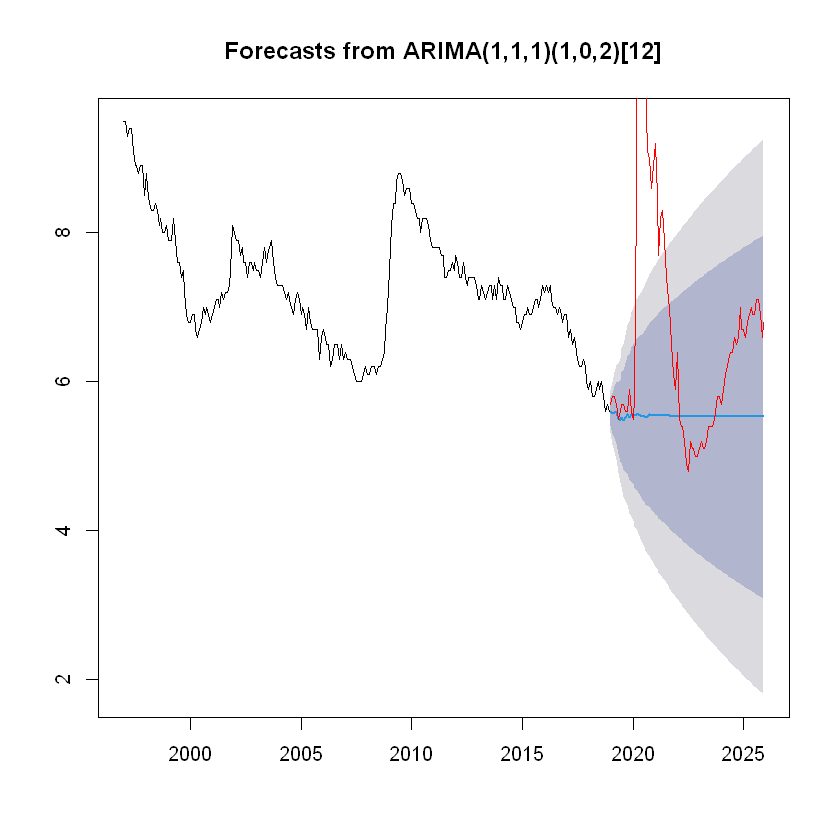

In [9]:
#test set
arima_fc <- forecast(fit_auto, h=length(test))
plot(arima_fc)
lines(test, col="red")
accuracy(arima_fc, test)


Based on the RMSE, ARIMA performs slightly better than Holt’s model since it has lower RMSE. However, it still struggles to capture the sudden spike during COVID, leading to large prediction errors.

The forecasts are relatively flat and fail to adapt to abrupt changes in the data. 

Thus, univariate models may be insufficient motivating the use of ARIMAX models
with external economic indicators.


In [10]:
# trying a few more models - we need differencing due to non staionarity
fit1 <- Arima(train, order=c(1,1,1))
fit2 <- Arima(train, order=c(2,1,1))
fit3 <- Arima(train, order=c(1,1,2))
# adding extra models as suggested in EDA
fit4 <- Arima(train, order=c(0,1,1))
fit5 <- Arima(train, order=c(1,1,0))

In [11]:
AIC(fit_auto, fit1, fit2, fit3, fit4, fit5)

,df,AIC
,<dbl>,<dbl>
fit_auto,6,-262.3435
fit1,3,-237.2648
fit2,4,-237.6317
fit3,4,-238.0763
fit4,2,-234.0363
fit5,2,-234.0436


We observe that the model selected by auto.arima outperforms all the manual ARIMA models fitted above, as it has the lowest AIC (-262.34)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.01015301,0.1426689,0.1113921,-0.1493692,1.538004,0.2170983,-0.004710084,NA
Test set,1.16381953,2.1571472,1.3163273,12.9710162,15.975012,2.5654638,0.913020315,2.427475


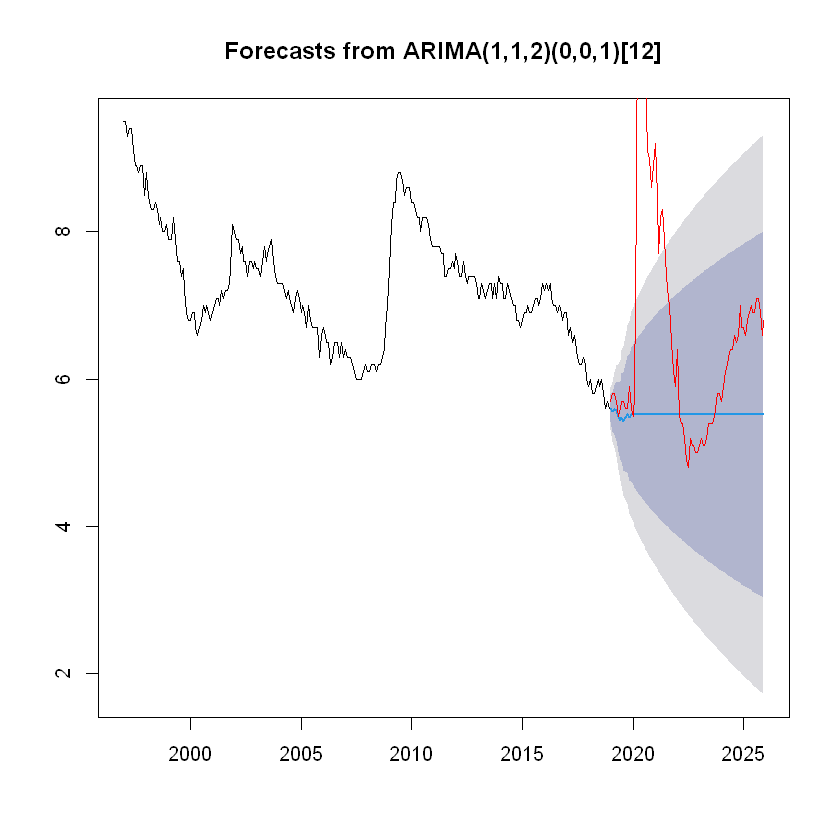

In [12]:
# trying for another model using
# >auto.arima(train, stepwise=FALSE, approximation=FALSE)
# gives us ARIMA(1,1,2)(0,0,1)[12] with AIC = -264.88

fit_new <- Arima(train, order=c(1,1,2), seasonal=c(0,0,1))
arima_fc_new <- forecast(fit_new, h=length(test))
plot(arima_fc_new)
lines(test, col="red")
accuracy(arima_fc_new, test)



In [14]:
AIC(fit_auto,fit_new)

,df,AIC
,<dbl>,<dbl>
fit_auto,6,-262.3435
fit_new,5,-264.8781


By comparing the ARIMA (1,1,1)(1,0,2)[12] and ARIMA(1,1,2)(0,0,1)[12], we
observe that first has a higher AIC(-262.34) but lower RMSE(2.14),whereas the
latter has a lower AIC (-264.88) and higher RMSE (2.15)

Thus, the new ARIMA model fits the training data better as indicated by the low AIC,
but does not improve prediction accuracy, indicated by higher RMSE.
Thus, this suggests overfitting and hence we consider ARIMA (1,1,1)(1,0,2)[12] as
our final ARIMA model.

The original series exhibits non-stationarity due to trend, which is also
addressed through first-order differencing (d = 1) in the ARIMA models.



	Ljung-Box test

data:  Residuals from Holt's method
Q* = 44.886, df = 24, p-value = 0.006008

Model df: 0.   Total lags used: 24



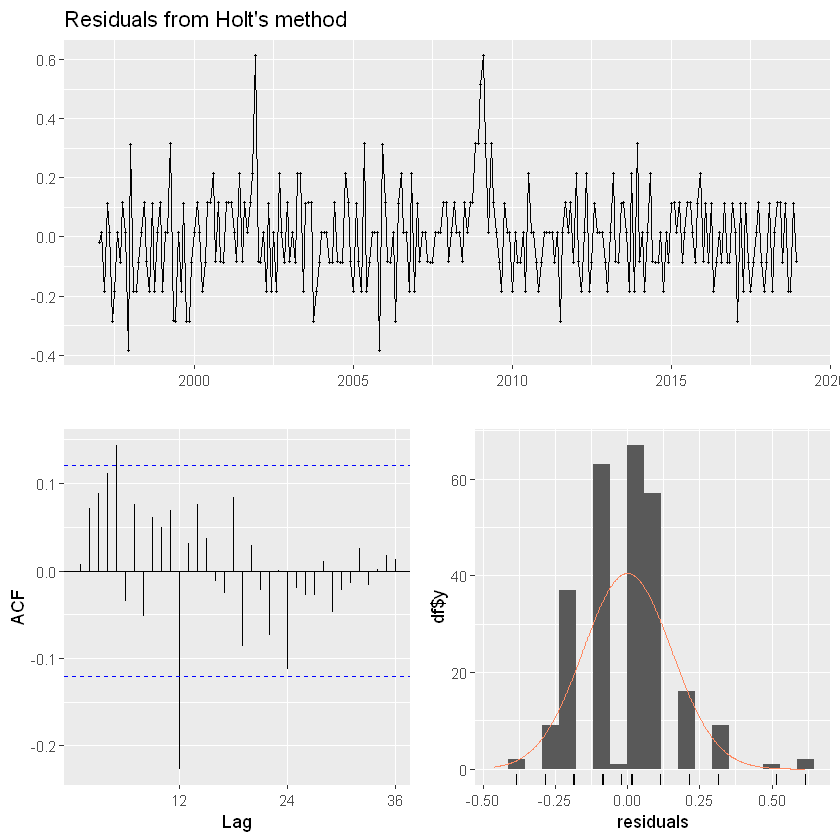


	Ljung-Box test

data:  Residuals from ARIMA(1,1,1)(1,0,2)[12]
Q* = 19.344, df = 19, p-value = 0.435

Model df: 5.   Total lags used: 24




	Box-Ljung test

data:  residuals(fit_auto)
X-squared = 18.231, df = 20, p-value = 0.5722


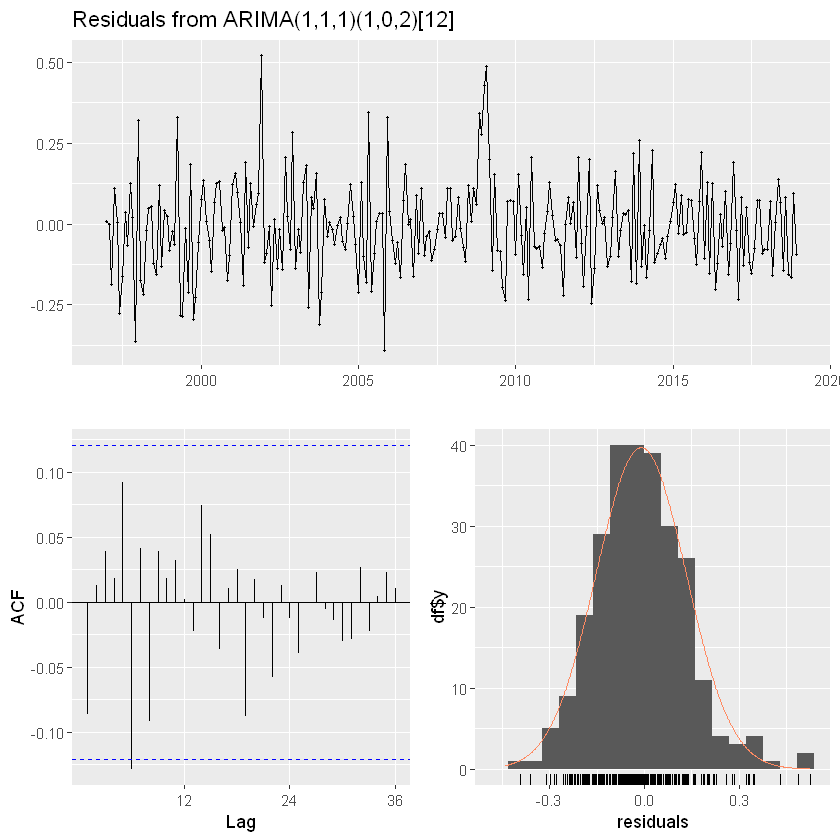

In [13]:
checkresiduals(holt_fc)
checkresiduals(fit_auto)
Box.test(residuals(fit_auto), lag=20, type="Ljung-Box")

The residual diagnostics for Holt’s method show significant autocorrelation,
indicating that the residuals are not random, and thus, says that the model fails
to capture temporal patterns in the data.
(Since the p-value is also 0.006 < 0.05, this also implies that we reject the
hypothesis that the residuals are random)

The ARIMA model produces residuals closer to white noise, with most
autocorrelations lying within the confidence bounds, thus, indicating that the
model captures underlying temporal dependence better than Holt’s method.
Here the p-value = 0.435 > 0.05 => we do not reject that the residuals are random


Similarly in the box test, we observe a p-value = 0.5722 > 0.05, thus we arrive
at the same conclusion of not rejecting for the ARIMA model
